In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/lendingclub_cleaned_outliers.csv")

In [3]:
print(df.shape)
print(df.isnull().sum().sum())

(2218133, 114)
0


In [4]:
print(df.dtypes.value_counts())
print(df.describe().T)

float64    70
int64      22
object     22
Name: count, dtype: int64
                              count          mean           std       min  \
id                        2218133.0  8.184957e+07  4.402840e+07  55716.00   
loan_amnt                 2218133.0  1.512281e+04  9.204402e+03   1000.00   
funded_amnt               2218133.0  1.512259e+04  9.204260e+03   1000.00   
funded_amnt_inv           2218133.0  1.511708e+04  9.202063e+03    725.00   
int_rate                  2218133.0  1.311062e+01  4.849417e+00      5.31   
...                             ...           ...           ...       ...   
mo_sin_old_il_acct_999    2218133.0  9.016592e-07  9.495572e-04      0.00   
mo_sin_old_rev_tl_op_999  2218133.0  4.508296e-07  6.714385e-04      0.00   
total_rev_hi_lim_9999999  2218133.0  1.352489e-06  1.162965e-03      0.00   
tot_hi_cred_lim_9999999   2218133.0  6.311614e-06  2.512285e-03      0.00   
dti_invalid               2218133.0  1.093713e-03  3.305324e-02      0.00   

       

Analyze the target variable

In [5]:
print(df["loan_status"].value_counts())

loan_status
Fully Paid            1042635
Current                878317
Charged Off            262889
Late (31-120 days)      21467
In Grace Period          8436
Late (16-30 days)        4349
Default                    40
Name: count, dtype: int64


In [6]:
print(df["loan_status"].value_counts(normalize=True) * 100)

loan_status
Fully Paid            47.005071
Current               39.597130
Charged Off           11.851814
Late (31-120 days)     0.967796
In Grace Period        0.380320
Late (16-30 days)      0.196066
Default                0.001803
Name: proportion, dtype: float64


Analyze loan amount distribution

count    2.218133e+06
mean     1.512281e+04
std      9.204402e+03
min      1.000000e+03
25%      8.000000e+03
50%      1.300000e+04
75%      2.000000e+04
max      4.000000e+04
Name: loan_amnt, dtype: float64


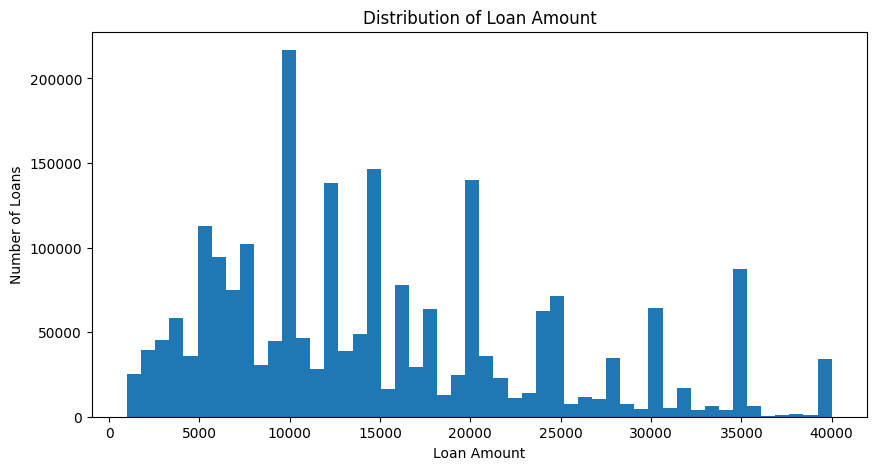

In [7]:
print(df['loan_amnt'].describe())

plt.figure(figsize=(10, 5))
plt.hist(df['loan_amnt'], bins=50)
plt.xlabel("Loan Amount")
plt.ylabel("Number of Loans")
plt.title("Distribution of Loan Amount")
plt.show()

Check loan amount by loan_status

In [8]:
df.groupby("loan_status")["loan_amnt"].agg(["count", "mean", "median"])

,count,mean,median
loan_status,,,
Charged Off,262889,15638.765601,14400.0
Current,878317,15942.815920,14000.0
Default,40,14350.625000,10475.0
Fully Paid,1042635,14234.341069,12000.0
In Grace Period,8436,17672.558084,16000.0
Late (16-30 days),4349,17391.118648,15000.0
Late (31-120 days),21467,16946.614571,15000.0


Analyze relationship with a boxplot

<Figure size 1000x600 with 0 Axes>

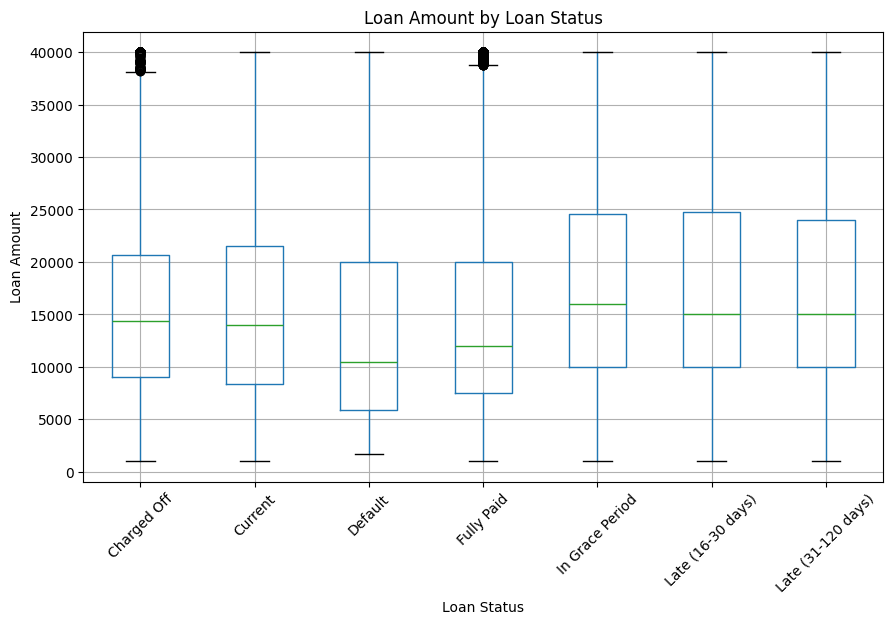

In [9]:
plt.figure(figsize=(10, 6))

df.boxplot(column="loan_amnt", by="loan_status", figsize=(10, 6))

plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.title("Loan Amount by Loan Status")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

Check interest rate by loan_status

In [10]:
df.groupby("loan_status")["int_rate"].agg(["count", "mean", "median"])

,count,mean,median
loan_status,,,
Charged Off,262889,15.751116,15.05
Current,878317,12.768128,11.99
Default,40,16.181750,16.73
Fully Paid,1042635,12.652612,12.29
In Grace Period,8436,15.461246,14.99
Late (16-30 days),4349,15.411380,14.52
Late (31-120 days),21467,15.637190,14.99


<Figure size 1000x600 with 0 Axes>

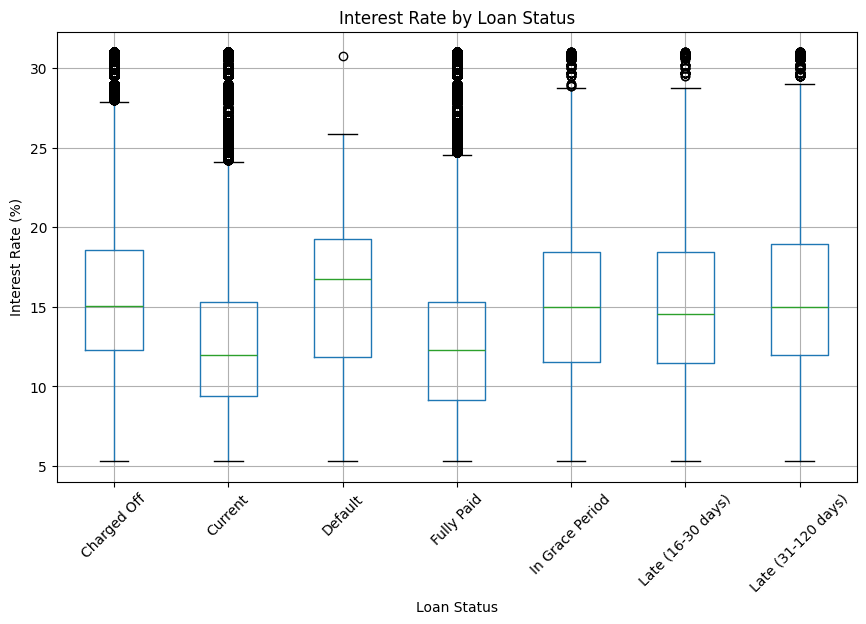

In [11]:
plt.figure(figsize=(10, 6))

df.boxplot(column="int_rate", by="loan_status", figsize=(10, 6))

plt.xlabel("Loan Status")
plt.ylabel("Interest Rate (%)")
plt.title("Interest Rate by Loan Status")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

Check annual income by loan status

In [12]:
df.groupby("loan_status")["annual_inc"].agg(["count", "mean", "median"])

,count,mean,median
loan_status,,,
Charged Off,262889,70113.214544,60000.0
Current,878317,79659.371451,67000.0
Default,40,74176.800000,61000.0
Fully Paid,1042635,77414.596312,65000.0
In Grace Period,8436,80686.323224,69600.0
Late (16-30 days),4349,79160.604254,67600.0
Late (31-120 days),21467,75986.618997,65000.0


<Figure size 1000x600 with 0 Axes>

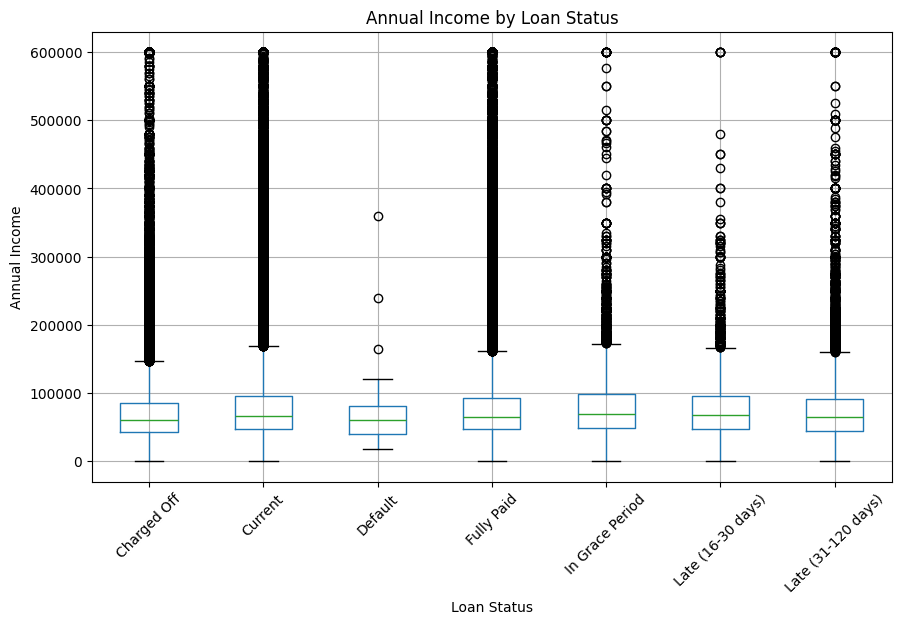

In [13]:
plt.figure(figsize=(10, 6))

df.boxplot(column="annual_inc", by="loan_status", figsize=(10, 6))

plt.xlabel("Loan Status")
plt.ylabel("Annual Income")
plt.title("Annual Income by Loan Status")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

Check grade distribution

Count each grade

In [14]:
print(df["grade"].value_counts().sort_index())

grade
A    422844
B    651168
C    641313
D    318408
E    132245
F     40499
G     11656
Name: count, dtype: int64


Percentage of each grade

In [15]:
print(df["grade"].value_counts(normalize=True).sort_index() * 100)

grade
A    19.063059
B    29.356581
C    28.912288
D    14.354775
E     5.961996
F     1.825815
G     0.525487
Name: proportion, dtype: float64


In [16]:
print(pd.crosstab(df["grade"], df["loan_status"], normalize="index") * 100)

loan_status  Charged Off    Current   Default  Fully Paid  In Grace Period  \
grade                                                                        
A               3.216080  46.243768  0.001182   49.996216         0.149464   
B               7.852966  40.374066  0.001075   50.612131         0.271973   
C              13.143816  39.872418  0.001247   45.107771         0.466699   
D              18.819879  36.160524  0.004083   42.619532         0.596405   
E              26.700442  28.795040  0.004537   41.953949         0.604182   
F              34.983580  20.951135  0.002469   41.571397         0.592607   
G              38.254976  21.147907  0.000000   37.362732         0.875086   

loan_status  Late (16-30 days)  Late (31-120 days)  
grade                                               
A                     0.080644            0.312645  
B                     0.152495            0.735294  
C                     0.230153            1.177896  
D                     0.304327  

A good finding for portfolio:

Loan grade has a strong relationship with loan performance. Higher-quality grades such as A and B have relatively low Charged Off rates, while lower-quality grades such as E, F, and G have substantially higher Charged Off rates. The percentage of Current loans generally decreases as grade worsens, indicating that loan grade is an important indicator of credit risk.

Check number of loans in home-ownership

In [17]:
print(df["home_ownership"].value_counts())

home_ownership
MORTGAGE    1092491
RENT         874748
OWN          249806
ANY             996
NONE             46
OTHER            46
Name: count, dtype: int64


In [18]:
print(df["home_ownership"].value_counts(normalize=True) * 100)

home_ownership
MORTGAGE    49.252727
RENT        39.436229
OWN         11.261994
ANY          0.044903
NONE         0.002074
OTHER        0.002074
Name: proportion, dtype: float64


In [19]:
print(pd.crosstab(df["home_ownership"], df["loan_status"], normalize="index") * 100)

loan_status     Charged Off    Current   Default  Fully Paid  In Grace Period  \
home_ownership                                                                  
ANY                5.622490  68.775100  0.000000   23.092369         0.602410   
MORTGAGE          10.268277  39.296250  0.001556   49.034363         0.370804   
NONE              15.217391   2.173913  0.000000   82.608696         0.000000   
OTHER             19.565217   0.000000  0.000000   80.434783         0.000000   
OWN               11.776338  41.569058  0.003202   44.974901         0.383097   
RENT              13.857591  39.380599  0.001715   45.074010         0.391198   

loan_status     Late (16-30 days)  Late (31-120 days)  
home_ownership                                         
ANY                      0.100402            1.807229  
MORTGAGE                 0.176752            0.851998  
NONE                     0.000000            0.000000  
OTHER                    0.000000            0.000000  
OWN            

Among the major home-ownership groups, renters have the highest Charged Off rate, while mortgage borrowers have the lowest. Home ownership therefore appears to have some relationship with loan performance.

Visualize this relationship

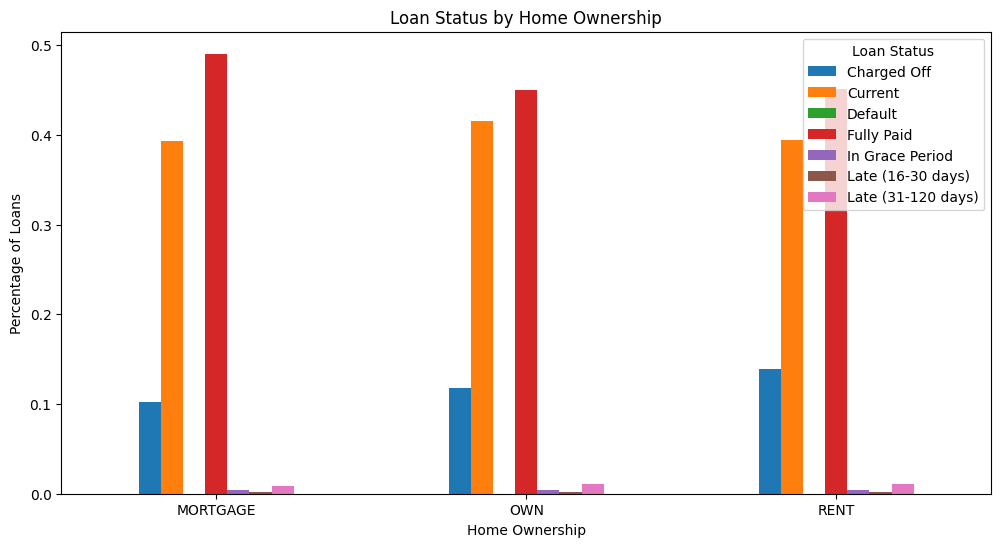

In [23]:
df_plot = df[~df["home_ownership"].isin(["ANY", "NONE", "OTHER"])]

pd.crosstab(df_plot["home_ownership"], df_plot["loan_status"], normalize="index").plot(kind="bar", figsize=(12, 6))

plt.ylabel("Percentage of Loans")
plt.xlabel("Home Ownership")
plt.title("Loan Status by Home Ownership")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")
plt.show()

Check how many loans are in each verification category

In [24]:
print(df["verification_status"].value_counts())

verification_status
Source Verified    875925
Not Verified       726048
Verified           616160
Name: count, dtype: int64


In [25]:
print(df["verification_status"].value_counts(normalize=True) * 100)

verification_status
Source Verified    39.489291
Not Verified       32.732393
Verified           27.778316
Name: proportion, dtype: float64


Check loan status within each verification category

In [26]:
print(pd.crosstab(df["verification_status"], df["loan_status"], normalize="index") * 100)

loan_status          Charged Off    Current   Default  Fully Paid  \
verification_status                                                 
Not Verified            7.904574  45.190263  0.001102   45.642161   
Source Verified        12.304706  39.980592  0.001827   46.062962   
Verified               15.859192  32.461374  0.002597   49.950338   

loan_status          In Grace Period  Late (16-30 days)  Late (31-120 days)  
verification_status                                                          
Not Verified                0.309346           0.164865            0.787689  
Source Verified             0.408026           0.208808            1.033079  
Verified                    0.424565           0.214717            1.087218  


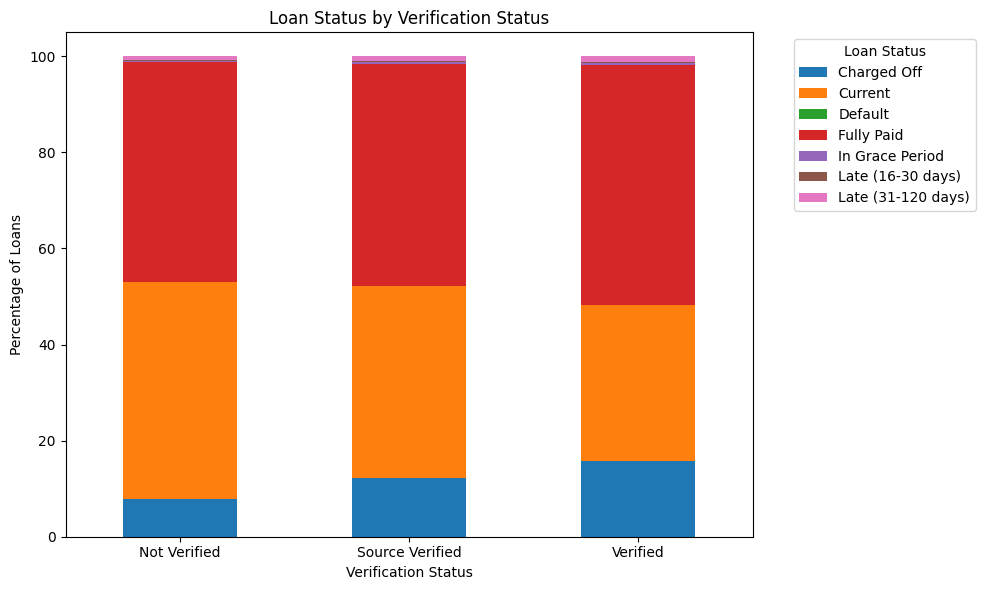

In [27]:
crosstab = pd.crosstab(df["verification_status"], df["loan_status"], normalize="index") * 100

crosstab.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.xlabel("Verification Status")
plt.ylabel("Percentage of Loans")
plt.title("Loan Status by Verification Status")
plt.xticks(rotation=0)
plt.legend(title="Loan Status", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Check the Purpose

In [28]:
print(df["purpose"].value_counts())

purpose
debt_consolidation    1258101
credit_card            511494
home_improvement       147258
other                  135015
major_purchase          48134
medical                 26735
small_business          22697
car                     22398
vacation                15125
moving                  14774
house                   13710
wedding                  1351
renewable_energy         1339
educational                 2
Name: count, dtype: int64


In [29]:
print(df["purpose"].value_counts(normalize=True) * 100)

purpose
debt_consolidation    56.718916
credit_card           23.059663
home_improvement       6.638826
other                  6.086876
major_purchase         2.170023
medical                1.205293
small_business         1.023248
car                    1.009768
vacation               0.681880
moving                 0.666056
house                  0.618087
wedding                0.060907
renewable_energy       0.060366
educational            0.000090
Name: proportion, dtype: float64


Check purpose vs loan status

In [30]:
print(pd.crosstab(df["purpose"], df["loan_status"], normalize="index") * 100)

loan_status         Charged Off    Current   Default  Fully Paid  \
purpose                                                            
car                    8.844540  40.467899  0.013394   49.348156   
credit_card            9.664629  42.002448  0.001173   47.059790   
debt_consolidation    12.894195  37.869774  0.001669   47.645062   
educational            0.000000  50.000000  0.000000   50.000000   
home_improvement      10.288745  41.024596  0.002037   47.106439   
house                 11.145150  47.760759  0.007294   38.971554   
major_purchase        10.909129  41.617152  0.004155   45.676653   
medical               12.272302  42.734244  0.007481   43.306527   
moving                14.363070  37.884121  0.000000   45.857588   
other                 11.663889  43.443321  0.001481   43.051513   
renewable_energy      15.085885  36.594473  0.000000   46.900672   
small_business        18.068467  37.850817  0.000000   41.785258   
vacation              11.140496  41.104132  0.00

Purpose distribution is highly imbalanced, Loan outcomes differe by purpose, and be carefull with small categories

In [32]:
charged_off_rate = (pd.crosstab(df["purpose"], df["loan_status"], normalize="index")["Charged Off"] * 100).sort_values(ascending=False)
print(charged_off_rate)

purpose
small_business        18.068467
renewable_energy      15.085885
moving                14.363070
wedding               13.545522
debt_consolidation    12.894195
medical               12.272302
other                 11.663889
house                 11.145150
vacation              11.140496
major_purchase        10.909129
home_improvement      10.288745
credit_card            9.664629
car                    8.844540
educational            0.000000
Name: Charged Off, dtype: float64


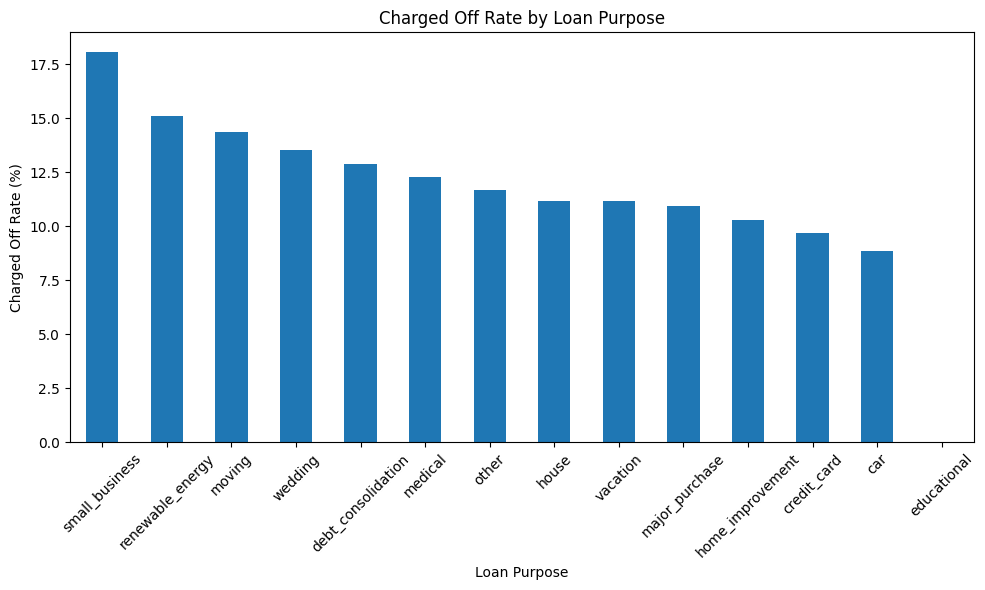

In [33]:
plt.figure(figsize=(10, 6))
charged_off_rate.plot(kind="bar")

plt.xlabel("Loan Purpose")
plt.ylabel("Charged Off Rate (%)")
plt.title("Charged Off Rate by Loan Purpose")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Educational charged off rate is 0 because it has only 2 loans

"Small-business loans show the highest observed Charged-Off rate in this dataset, although differences in sample size and other borrower characteristics should be considered."

Analyze term

In [34]:
print(df["term"].value_counts())

term
36 months    1578220
60 months     639913
Name: count, dtype: int64


In [35]:
print(df["term"].value_counts(normalize=True) * 100)

term
36 months    71.150828
60 months    28.849172
Name: proportion, dtype: float64


In [36]:
print(pd.crosstab(df["term"], df["loan_status"], normalize="index") * 100)

loan_status  Charged Off    Current   Default  Fully Paid  In Grace Period  \
term                                                                         
36 months      10.139588  35.907225  0.001584   52.693668         0.306294   
60 months      16.074685  48.697557  0.002344   32.975264         0.562889   

loan_status  Late (16-30 days)  Late (31-120 days)  
term                                                
36 months             0.161258            0.790384  
60 months             0.281913            1.405347  


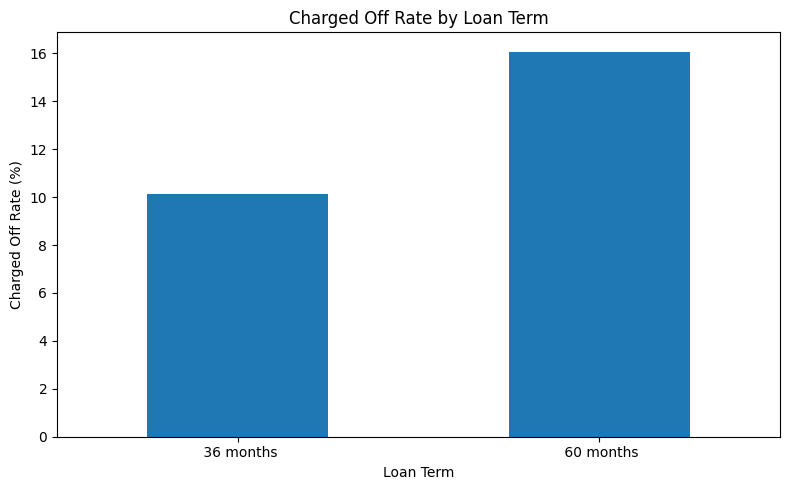

In [39]:
charged_off_rate = (pd.crosstab(df["term"], df["loan_status"], normalize="index")["Charged Off"] * 100)

plt.figure(figsize=(8, 5))
charged_off_rate.plot(kind="bar")
plt.xlabel("Loan Term")
plt.ylabel("Charged Off Rate (%)")
plt.title("Charged Off Rate by Loan Term")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

That's a useful finding for your portfolio because term could be an important predictor of loan risk.
One caution: this shows association, not causation. We can't conclude that simply choosing 60 months causes the higher default risk.

Analyze dti(debt-to-income ratio) by loan status

In [40]:
print(df.groupby("loan_status")["dti"].agg(["count", "mean", "median"]))

                      count       mean  median
loan_status                                   
Charged Off          262889  20.177420  19.890
Current              878317  19.130498  18.100
Default                  40  17.263250  14.740
Fully Paid          1042635  17.867367  17.250
In Grace Period        8436  19.957927  18.855
Late (16-30 days)      4349  19.190269  18.460
Late (31-120 days)    21467  19.583347  18.750


<Figure size 1000x600 with 0 Axes>

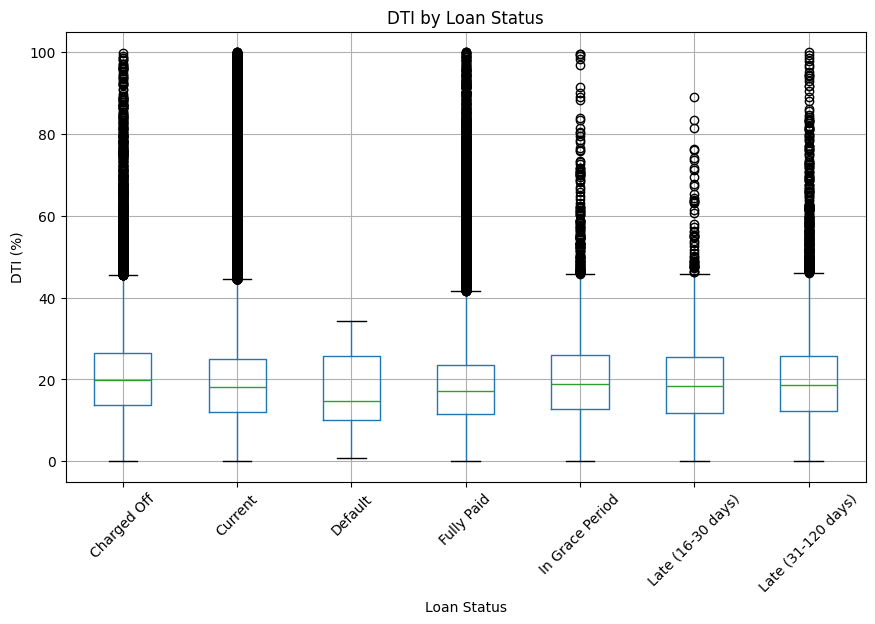

In [41]:
plt.figure(figsize=(10, 6))
df.boxplot(column="dti", by="loan_status", figsize=(10, 6))

plt.xlabel("Loan Status")
plt.ylabel("DTI (%)")
plt.title("DTI by Loan Status")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

Charged-off seems to have higher DTI values than fully paid and current loans, which means that higher debt-to-income ratios may be associated with increased credit card. and default has 40 observations, so don't rely on it.

Analyze installment

In [46]:
df.groupby("loan_status")["installment"].agg(["count", "mean", "median"])

,count,mean,median
loan_status,,,
Charged Off,262889,467.915979,405.950
Current,878317,455.755848,383.160
Default,40,438.939250,311.670
Fully Paid,1042635,434.876614,371.590
In Grace Period,8436,519.533225,464.705
Late (16-30 days),4349,512.877211,447.830
Late (31-120 days),21467,500.393730,434.890


<Figure size 1000x600 with 0 Axes>

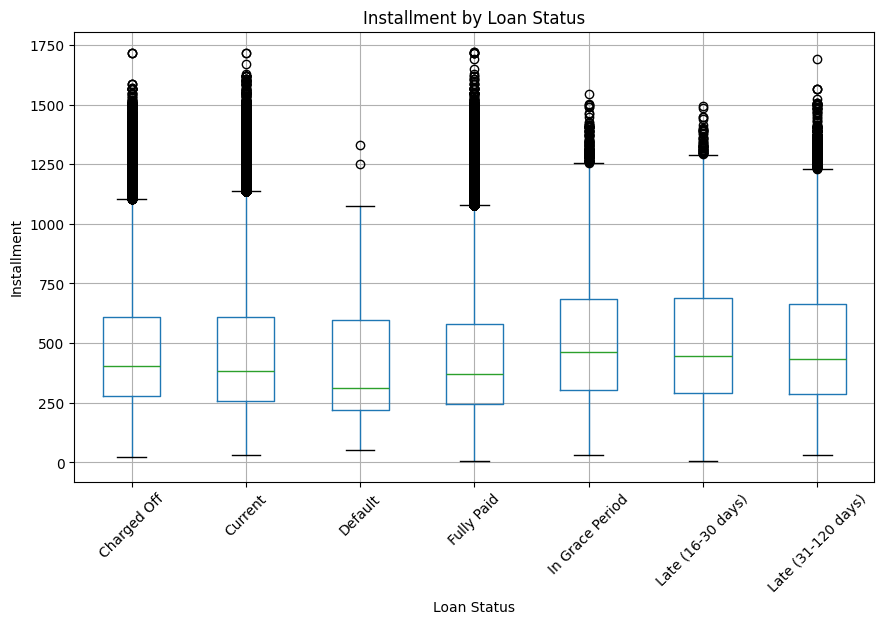

In [44]:
plt.figure(figsize=(10, 6))
df.boxplot(column="installment", by="loan_status", figsize=(10, 6))

plt.xlabel("Loan Status")
plt.ylabel("Installment")
plt.title("Installment by Loan Status")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

Analyze FICO score range

In [6]:
df["fico_score"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

In [7]:
df.groupby("loan_status")["fico_score"].agg(["count", "mean", "median"])

,count,mean,median
loan_status,,,
Charged Off,262889,689.509717,682.0
Current,878317,704.561296,697.0
Default,40,705.375000,694.5
Fully Paid,1042635,699.654631,692.0
In Grace Period,8436,693.344832,687.0
Late (16-30 days),4349,695.215797,687.0
Late (31-120 days),21467,694.318768,687.0


There is some relationship between FICO score and loan status, but it isn't extremely strong from these averages alone. Notice the difference isn't huge, so FICO alone won't determine whether a loan defaults.

<Figure size 1000x600 with 0 Axes>

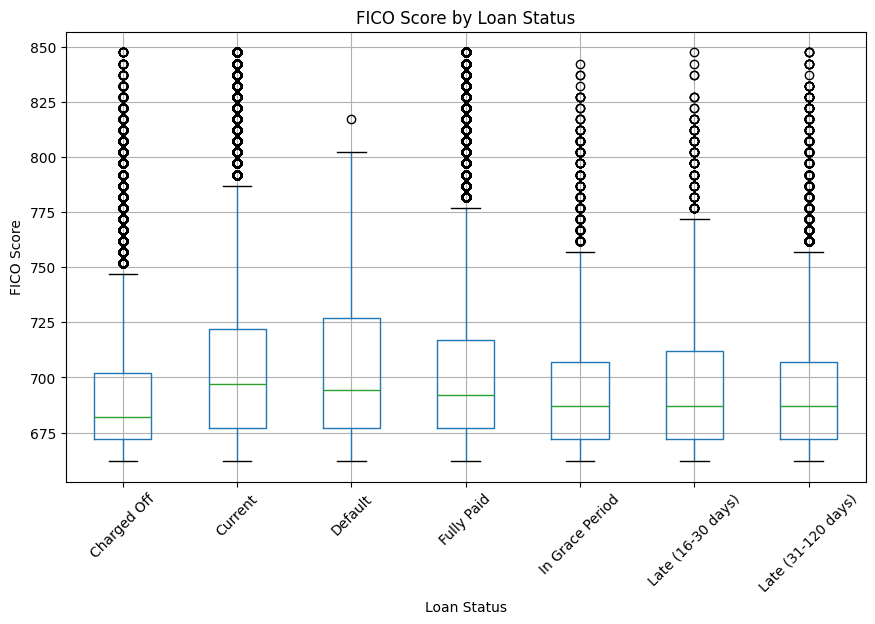

In [48]:
plt.figure(figsize=(10, 6))
df.boxplot(column="fico_score", by="loan_status", figsize=(10, 6))

plt.xlabel("Loan Status")
plt.ylabel("FICO Score")
plt.title("FICO Score by Loan Status")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

The boxplot shows substantial overlap between the groups.

Current: FICO can be low or high.
Charged Off: FICO can also be low or high.
FICO is a useful feature that may contribute to predicting loan status, together with other variables

Analyze revol_util (Revolving credit utilization)

In [50]:
df.groupby("loan_status")["revol_util"].agg(["count", "mean", "median"])

,count,mean,median
loan_status,,,
Charged Off,262889,54.736919,55.50
Current,878317,48.068607,47.30
Default,40,43.595000,40.90
Fully Paid,1042635,51.183368,51.30
In Grace Period,8436,53.355832,53.85
Late (16-30 days),4349,50.050310,50.00
Late (31-120 days),21467,49.524587,49.30


Charged off borrowers tend to have higher revl_util which suggest it could be useful feature for classification model but the difference isn't huge so it should be used together with other features.

<Figure size 1000x600 with 0 Axes>

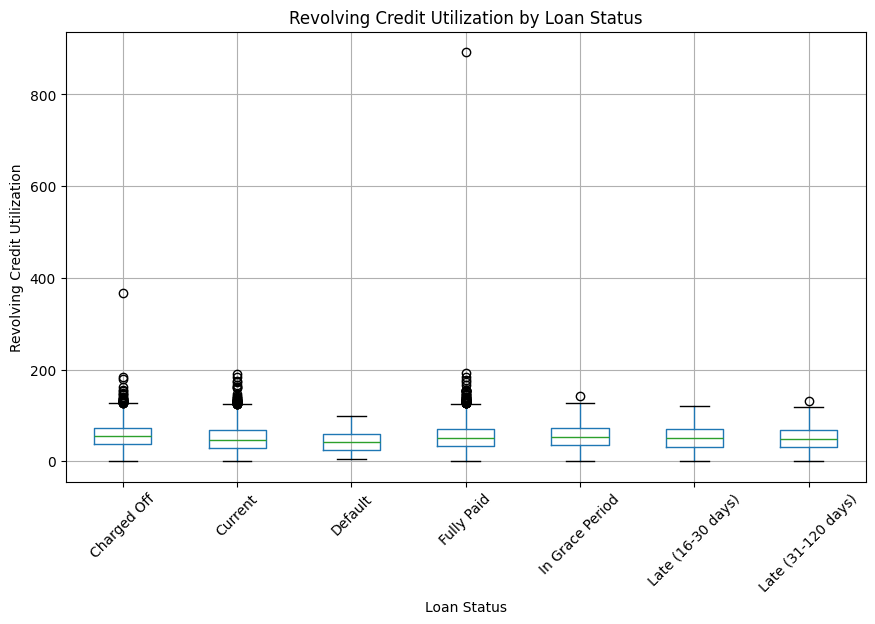

In [53]:
plt.figure(figsize=(10, 6))
df.boxplot(column="revol_util", by="loan_status", figsize=(10, 6))

plt.xlabel("Loan Status")
plt.ylabel("Revolving Credit Utilization")
plt.title("Revolving Credit Utilization by Loan Status")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

Check the values above 100%

In [54]:
df["revol_util"].describe()

count    2.218133e+06
mean     5.036102e+01
std      2.462778e+01
min      0.000000e+00
25%      3.160000e+01
50%      5.030000e+01
75%      6.930000e+01
max      8.923000e+02
Name: revol_util, dtype: float64

In [57]:
print((df["revol_util"] > 100).sum())
print((df["revol_util"] > 200).sum())
print((df["revol_util"] > 300).sum())
print((df["revol_util"] > 500).sum())

7316
2
2
1


In [58]:
df["revol_util"].quantile(0.999)

np.float64(102.2)

Cap values above 102.2%

In [59]:
upper = df["revol_util"].quantile(0.999)
df["revol_util"] = df["revol_util"].clip(upper=upper)

In [60]:
df["revol_util"].describe()

count    2.218133e+06
mean     5.035441e+01
std      2.460485e+01
min      0.000000e+00
25%      3.160000e+01
50%      5.030000e+01
75%      6.930000e+01
max      1.022000e+02
Name: revol_util, dtype: float64

Analyze emp_length

In [61]:
print(df["emp_length"].value_counts())

emp_length
10.0    738636
6.0     246048
2.0     198934
0.0     184926
3.0     176389
1.0     144808
5.0     136240
4.0     132956
7.0      90820
8.0      90322
9.0      78054
Name: count, dtype: int64


In [62]:
print(df["emp_length"].value_counts(normalize=True) * 100)

emp_length
10.0    33.299897
6.0     11.092572
2.0      8.968533
0.0      8.337011
3.0      7.952138
1.0      6.528373
5.0      6.142102
4.0      5.994050
7.0      4.094434
8.0      4.071983
9.0      3.518905
Name: proportion, dtype: float64


In [63]:
print(pd.crosstab(df["emp_length"], df["loan_status"], normalize="index") * 100)

loan_status  Charged Off    Current   Default  Fully Paid  In Grace Period  \
emp_length                                                                   
0.0            11.648443  42.298000  0.002163   44.304208         0.419087   
1.0            12.249323  39.550992  0.000691   46.619662         0.385338   
2.0            11.834578  39.425639  0.004021   47.154333         0.399127   
3.0            11.864685  39.724132  0.002835   46.811876         0.385512   
4.0            11.608352  40.336653  0.001504   46.389783         0.409910   
5.0            11.770405  39.082501  0.000000   47.586612         0.389753   
6.0            13.302689  42.154783  0.002845   42.757511         0.392606   
7.0            12.504955  34.979079  0.000000   51.191368         0.309403   
8.0            13.168442  33.071677  0.003321   52.392551         0.348752   
9.0            12.783458  35.057781  0.000000   50.862224         0.317729   
10.0           11.062147  39.901115  0.001354   47.600036       

As a result, employment length appears to have a weak relationship with loan status compared with variables that show stronger difference across loan outcomes.

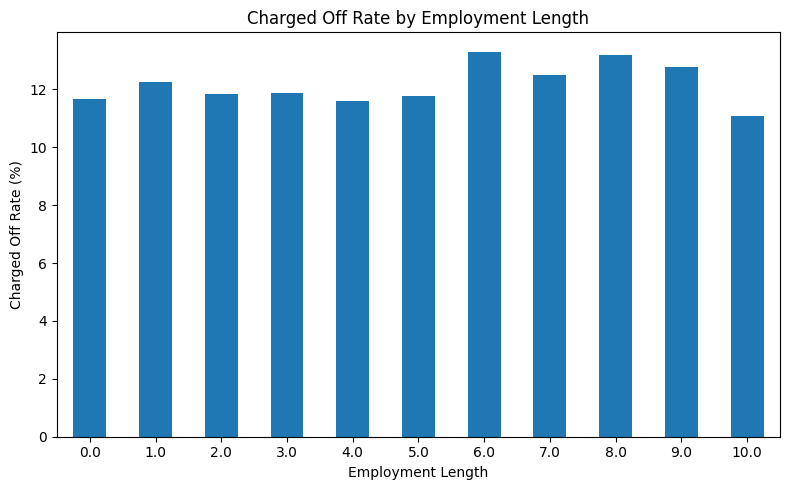

In [64]:
charged_off_rate = (pd.crosstab(df["emp_length"], df["loan_status"], normalize="index")["Charged Off"] * 100)

plt.figure(figsize=(8, 5))
charged_off_rate.plot(kind="bar")
plt.xlabel("Employment Length")
plt.ylabel("Charged Off Rate (%)")
plt.title("Charged Off Rate by Employment Length")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

there isn't a clear pattern that the longer someone has been employed, the lower their chance of charge-off.

Analyze public record problems

In [6]:
df.groupby("loan_status")["pub_rec"].agg(["count", "mean", "median"])

,count,mean,median
loan_status,,,
Charged Off,262889,0.250338,0.0
Current,878317,0.169382,0.0
Default,40,0.275000,0.0
Fully Paid,1042635,0.212546,0.0
In Grace Period,8436,0.211475,0.0
Late (16-30 days),4349,0.210163,0.0
Late (31-120 days),21467,0.240742,0.0


median is 0 because at least 50% of borrowers in each loan-status group have zero public record problems. More problematic loan statuses tend to have higher pub_rec. but the relationship is not very strong.

<Figure size 1000x600 with 0 Axes>

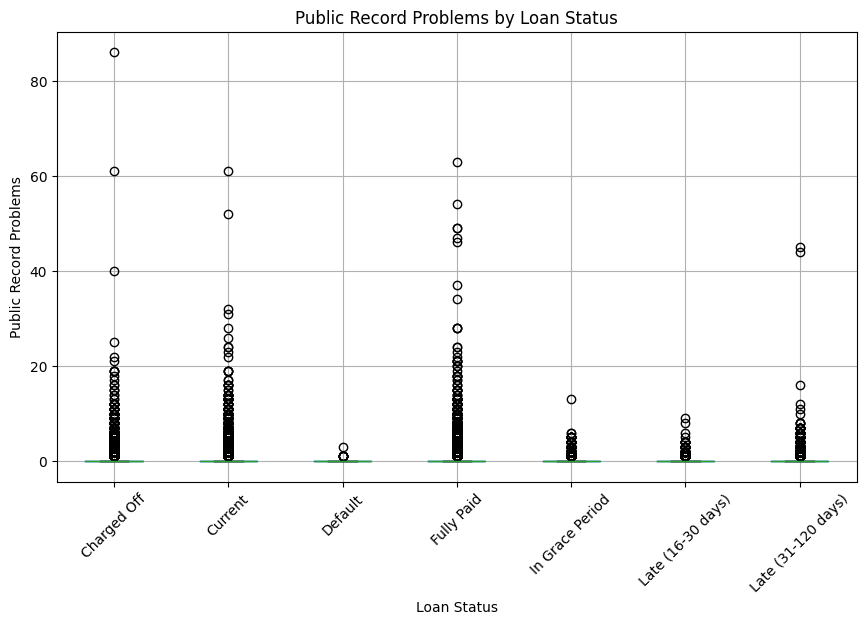

In [7]:
plt.figure(figsize=(10, 6))
df.boxplot(column="pub_rec", by="loan_status", figsize=(10, 6))

plt.xlabel("Loan Status")
plt.ylabel("Public Record Problems")
plt.title("Public Record Problems by Loan Status")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

pub_rec is highly right-skewed, with a median of 0 across all loan-status groups, indicating that most borrowers have no derogatory public records. it shows a weak relationship between public record problems and loan performance. The boxplot shows numerous high-value observations, but these should not automatically be treated as errors or capped because they may represent legitimate borrowers with multiple public records.

In [8]:
df["pub_rec"].describe()

count    2.218133e+06
mean     2.001985e-01
std      5.746202e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.600000e+01
Name: pub_rec, dtype: float64

In [9]:
print(df["pub_rec"].value_counts().sort_index())

pub_rec
0.0     1862628
1.0      303092
2.0       34090
3.0       10556
4.0        3870
5.0        1842
6.0         933
7.0         427
8.0         243
9.0         143
10.0         91
11.0         58
12.0         35
13.0         30
14.0         12
15.0         11
16.0         11
17.0          5
18.0          6
19.0          9
20.0          3
21.0          6
22.0          3
23.0          2
24.0          4
25.0          1
26.0          1
28.0          4
31.0          1
32.0          1
34.0          1
37.0          1
40.0          1
44.0          1
45.0          1
46.0          1
47.0          1
49.0          2
52.0          1
54.0          1
61.0          2
63.0          1
86.0          1
Name: count, dtype: int64


In [10]:
print(df[df["pub_rec"] >= 20]["pub_rec"].value_counts().sort_index())

pub_rec
20.0    3
21.0    6
22.0    3
23.0    2
24.0    4
25.0    1
26.0    1
28.0    4
31.0    1
32.0    1
34.0    1
37.0    1
40.0    1
44.0    1
45.0    1
46.0    1
47.0    1
49.0    2
52.0    1
54.0    1
61.0    2
63.0    1
86.0    1
Name: count, dtype: int64


pub_rec is a count public-record problems, so a high value can be a legitimate borrower characteristic.

Analyze total number of credit acounts

In [12]:
df.groupby("loan_status")["total_acc"].agg(["count", "mean", "median"])

,count,mean,median
loan_status,,,
Charged Off,262889,24.779500,23.0
Current,878317,22.952884,21.0
Default,40,21.850000,17.5
Fully Paid,1042635,25.141904,23.0
In Grace Period,8436,23.422949,21.0
Late (16-30 days),4349,22.774661,21.0
Late (31-120 days),21467,23.146038,21.0


total_acc does not appear to have a strong relationship with loan status by itself.

<Figure size 1000x600 with 0 Axes>

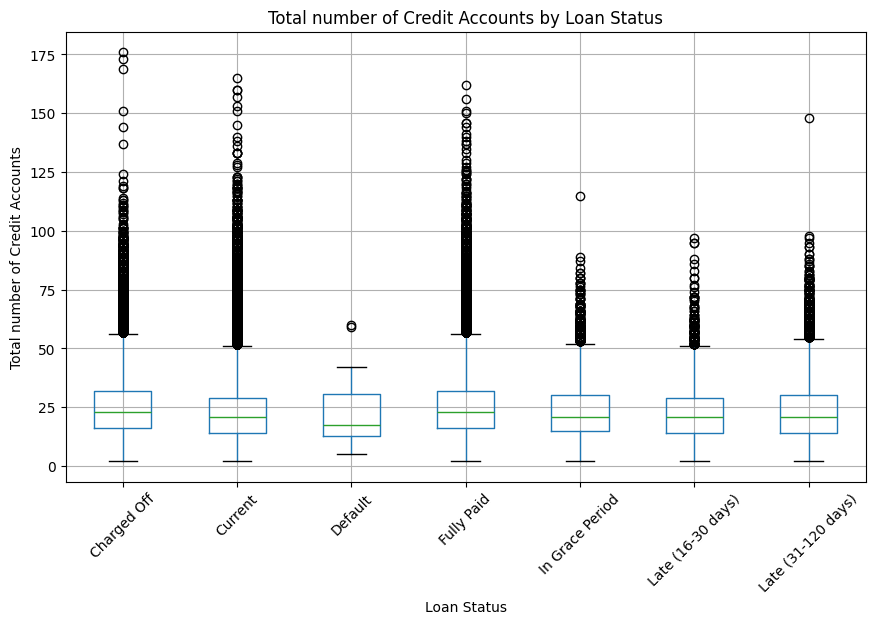

In [13]:
plt.figure(figsize=(10, 6))
df.boxplot(column="total_acc", by="loan_status", figsize=(10, 6))

plt.xlabel("Loan Status")
plt.ylabel("Total number of Credit Accounts")
plt.title("Total number of Credit Accounts by Loan Status")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

In [14]:
df["total_acc"].describe()

count    2.218133e+06
mean     2.420161e+01
std      1.199159e+01
min      2.000000e+00
25%      1.500000e+01
50%      2.200000e+01
75%      3.100000e+01
max      1.760000e+02
Name: total_acc, dtype: float64

In [15]:
print(df[df["total_acc"] > 100]["total_acc"].value_counts().sort_index())

total_acc
101.0    30
102.0    25
103.0    14
104.0    10
105.0    23
106.0    17
107.0    15
108.0     9
109.0    16
110.0    10
111.0     9
112.0     8
113.0    11
114.0     3
115.0     6
116.0     7
117.0     4
118.0     8
119.0     4
120.0     4
121.0     4
122.0     4
123.0     3
124.0     3
125.0     2
126.0     2
127.0     2
128.0     1
129.0     2
130.0     1
133.0     5
135.0     1
136.0     1
137.0     3
138.0     2
140.0     2
141.0     1
144.0     2
145.0     1
146.0     2
148.0     1
150.0     1
151.0     3
153.0     1
156.0     1
157.0     1
160.0     2
162.0     1
165.0     1
169.0     1
173.0     1
176.0     1
Name: count, dtype: int64


Correlation step

In [4]:
numerical_columns = df.select_dtypes(include=[np.number]).columns

corr = df[numerical_columns].corr()
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack().sort_values(key=abs, ascending=False)
)
print(corr_pairs.head(30))

mo_sin_rcnt_rev_tl_op_missing  mo_sin_old_rev_tl_op_missing    1.000000
fico_range_low                 fico_range_high                 1.000000
out_prncp                      out_prncp_inv                   0.999999
total_pymnt                    total_pymnt_inv                 0.999994
funded_amnt                    funded_amnt_inv                 0.999987
loan_amnt                      funded_amnt                     0.999986
mo_sin_rcnt_rev_tl_op_missing  mo_sin_rcnt_tl_missing          0.999982
mo_sin_old_rev_tl_op_missing   mo_sin_rcnt_tl_missing          0.999982
loan_amnt                      funded_amnt_inv                 0.999972
open_acc                       num_sats                        0.996797
num_actv_rev_tl                num_rev_tl_bal_gt_0             0.983644
tot_cur_bal                    tot_hi_cred_lim                 0.982669
recoveries                     collection_recovery_fee         0.974840
total_pymnt                    total_rec_prncp                 0

Create a list of pairs with correlation above 0.90

In [10]:
strong_corr = corr_pairs[abs(corr_pairs) >= 0.90]
print(strong_corr)

mo_sin_rcnt_rev_tl_op_missing  mo_sin_old_rev_tl_op_missing    1.000000
fico_range_low                 fico_range_high                 1.000000
out_prncp                      out_prncp_inv                   0.999999
total_pymnt                    total_pymnt_inv                 0.999994
funded_amnt                    funded_amnt_inv                 0.999987
loan_amnt                      funded_amnt                     0.999986
mo_sin_rcnt_rev_tl_op_missing  mo_sin_rcnt_tl_missing          0.999982
mo_sin_old_rev_tl_op_missing   mo_sin_rcnt_tl_missing          0.999982
loan_amnt                      funded_amnt_inv                 0.999972
open_acc                       num_sats                        0.996797
num_actv_rev_tl                num_rev_tl_bal_gt_0             0.983644
tot_cur_bal                    tot_hi_cred_lim                 0.982669
recoveries                     collection_recovery_fee         0.974840
total_pymnt                    total_rec_prncp                 0

Remove id because it is an identifier, not a meaningful borrower feature. and drop fico high and low because i already created fico score

In [ ]:
df = df.drop(columns=["id"])
df = df.drop(columns=["fico_range_low", "fico_range_high"])
df = df.drop(columns=["mo_sin_old_rev_tl_op_missing"])

In [20]:
numerical_columns = df.select_dtypes(include=[np.number]).columns

corr = df[numerical_columns].corr()

corr_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
              .stack().sort_values(key=abs, ascending=False))

strong_corr = corr_pairs[abs(corr_pairs) >= 0.90]
print(strong_corr)

out_prncp                      out_prncp_inv              0.999999
total_pymnt                    total_pymnt_inv            0.999994
funded_amnt                    funded_amnt_inv            0.999987
loan_amnt                      funded_amnt                0.999986
mo_sin_rcnt_rev_tl_op_missing  mo_sin_rcnt_tl_missing     0.999982
loan_amnt                      funded_amnt_inv            0.999972
open_acc                       num_sats                   0.996797
num_actv_rev_tl                num_rev_tl_bal_gt_0        0.983644
tot_cur_bal                    tot_hi_cred_lim            0.982669
recoveries                     collection_recovery_fee    0.974840
total_pymnt                    total_rec_prncp            0.966175
total_pymnt_inv                total_rec_prncp            0.966171
funded_amnt                    installment                0.945622
loan_amnt                      installment                0.945607
funded_amnt_inv                installment                0.94

In [21]:
df = df.drop(columns=["out_prncp_inv", "total_pymnt_inv", "funded_amnt_inv", "funded_amnt"])

In [22]:
numerical_columns = df.select_dtypes(include=[np.number]).columns

corr = df[numerical_columns].corr()

corr_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
              .stack().sort_values(key=abs, ascending=False))

strong_corr = corr_pairs[abs(corr_pairs) >= 0.90]
print(strong_corr)

mo_sin_rcnt_rev_tl_op_missing  mo_sin_rcnt_tl_missing     0.999982
open_acc                       num_sats                   0.996797
num_actv_rev_tl                num_rev_tl_bal_gt_0        0.983644
tot_cur_bal                    tot_hi_cred_lim            0.982669
recoveries                     collection_recovery_fee    0.974840
total_pymnt                    total_rec_prncp            0.966175
loan_amnt                      installment                0.945607
dtype: float64


In [28]:
df = df.drop(columns=["mo_sin_rcnt_tl_missing"])

In [31]:
(df["open_acc"] != df["num_sats"]).mean() * 100

np.float64(3.874204116705356)

In [34]:
(df["num_actv_rev_tl"] != df["num_rev_tl_bal_gt_0"]).mean() * 100

np.float64(4.315791704104307)

In [35]:
(df["tot_cur_bal"] != df["tot_hi_cred_lim"]).mean() * 100

np.float64(99.99639336324738)

Drop redundant features

In [38]:
df = df.drop(columns=["num_sats", "num_rev_tl_bal_gt_0"])

In [39]:
numerical_columns = df.select_dtypes(include=[np.number]).columns

corr = df[numerical_columns].corr()

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=abs, ascending=False)
)

strong_corr = corr_pairs[abs(corr_pairs) >= 0.90]

print(strong_corr)

tot_cur_bal  tot_hi_cred_lim            0.982669
recoveries   collection_recovery_fee    0.974840
total_pymnt  total_rec_prncp            0.966175
loan_amnt    installment                0.945607
dtype: float64


In [41]:
df = df.drop(columns=["recoveries", "collection_recovery_fee", "total_pymnt", "total_rec_prncp"])

In [42]:
df.shape

(2218133, 100)

Check missing

In [43]:
missing = df.isnull().mean() * 100
print(missing[missing > 0].sort_values(ascending=False))

Series([], dtype: float64)


Check Categorical columns

In [44]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns

print(categorical_columns)
print("Number of categorical columns:", len(categorical_columns))

Index(['term', 'grade', 'sub_grade', 'emp_title', 'home_ownership',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url',
       'purpose', 'title', 'zip_code', 'addr_state', 'earliest_cr_line',
       'initial_list_status', 'last_pymnt_d', 'last_credit_pull_d',
       'application_type', 'hardship_flag', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='object')
Number of categorical columns: 22


In [45]:
for col in categorical_columns:
    print(f"\n{col}:")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


term:
Unique values: 2
term
36 months    1578220
60 months     639913
Name: count, dtype: int64

grade:
Unique values: 7
grade
B    651168
C    641313
A    422844
D    318408
E    132245
F     40499
G     11656
Name: count, dtype: int64

sub_grade:
Unique values: 35
sub_grade
C1    143639
B5    137481
B4    137203
C2    128959
B3    128517
C3    127535
C4    125745
B2    124508
B1    123459
C5    115435
Name: count, dtype: int64

emp_title:
Unique values: 489723
emp_title
Unknown             164343
Teacher              38824
Manager              34298
Owner                21977
Registered Nurse     15867
Driver               14752
RN                   14737
Supervisor           14297
Sales                13050
Project Manager      10971
Name: count, dtype: int64

home_ownership:
Unique values: 6
home_ownership
MORTGAGE    1092491
RENT         874748
OWN          249806
ANY             996
NONE             46
OTHER            46
Name: count, dtype: int64

verification_status:
Unique va

In [46]:
drop_df = [
    "emp_title",
    "url",
    "title",
    "zip_code",
    "grade",
    "last_pymnt_d",
    "last_credit_pull_d",
    "hardship_flag",
    "debt_settlement_flag"
]

df = df.drop(columns=drop_df)

I dropped these because some of them had too many categories, contained leakage, and i also dropped grade because sub_grade gives more detailed grade information.

Convert issue_d and earliest_cr_line to date time

In [47]:
df["issue_d"] = pd.to_datetime(df["issue_d"])

In [48]:
df["issue_year"] = df["issue_d"].dt.year
df["issue_month"] = df["issue_d"].dt.month

In [49]:
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y")

In [50]:
df["credit_history_years"] = (df["issue_d"] - df["earliest_cr_line"]).dt.days / 365.25

In [51]:
df = df.drop(columns=["issue_d", "earliest_cr_line"])

In [52]:
df[["issue_year", "issue_month", "credit_history_years"]].describe()

,issue_year,issue_month,credit_history_years
count,2.218133e+06,2.218133e+06,2.218133e+06
mean,2.015966e+03,6.745295e+00,1.644681e+01
std,1.624373e+00,3.409088e+00,7.684663e+00
min,2.012000e+03,1.000000e+00,2.997947e+00
25%,2.015000e+03,4.000000e+00,1.133196e+01
50%,2.016000e+03,7.000000e+00,1.491307e+01
75%,2.017000e+03,1.000000e+01,2.033402e+01
max,2.018000e+03,1.200000e+01,8.325257e+01


In [70]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_columns:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


term
Unique values: 2
term
36 months    1578220
60 months     639913
Name: count, dtype: int64

sub_grade
Unique values: 35
sub_grade
C1    143639
B5    137481
B4    137203
C2    128959
B3    128517
C3    127535
C4    125745
B2    124508
B1    123459
C5    115435
Name: count, dtype: int64

home_ownership
Unique values: 6
home_ownership
MORTGAGE    1092491
RENT         874748
OWN          249806
ANY             996
NONE             46
OTHER            46
Name: count, dtype: int64

verification_status
Unique values: 3
verification_status
Source Verified    875925
Not Verified       726048
Verified           616160
Name: count, dtype: int64

loan_status
Unique values: 7
loan_status
Fully Paid            1042635
Current                878317
Charged Off            262889
Late (31-120 days)      21467
In Grace Period          8436
Late (16-30 days)        4349
Default                    40
Name: count, dtype: int64

pymnt_plan
Unique values: 2
pymnt_plan
n    2217513
y        620
Name: cou

Analyzing the target

In [56]:
df["loan_status"].value_counts()

loan_status
Fully Paid            1042635
Current                878317
Charged Off            262889
Late (31-120 days)      21467
In Grace Period          8436
Late (16-30 days)        4349
Default                    40
Name: count, dtype: int64

In [64]:
print(df.columns.tolist())

['loan_amnt', 'term', 'int_rate', 'installment', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'loan_status', 'pymnt_plan', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 't

Remove Leakage columns

In [62]:
leakage_cols = [
    "out_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "last_pymnt_amnt",
    "last_fico_range_high",
    "last_fico_range_low",
    "last_pymnt_d_missing",
    "last_credit_pull_d_missing",
    "next_pymnt_d_missing"
]

df = df.drop(columns=leakage_cols)

These would make the model unrealistically powerful because we are trying to predict the loan outcome without knowing its future.

In [67]:
df.shape

(2218133, 82)

In [65]:
nunique = df.nunique()
print(nunique[nunique==1])

policy_code    1
dtype: int64


In [66]:
df = df.drop(columns=["policy_code"])

Seperate target column from categorical features

In [71]:
categorical_features = df.select_dtypes(include=["object", "category"]).columns.drop("loan_status")

print(categorical_features)
print("Number:", len(categorical_features))

Index(['term', 'sub_grade', 'home_ownership', 'verification_status',
       'pymnt_plan', 'purpose', 'addr_state', 'initial_list_status',
       'application_type', 'disbursement_method'],
      dtype='object')
Number: 10


In [72]:
for col in categorical_features:
    print(col, ":", df[col].nunique())

term : 2
sub_grade : 35
home_ownership : 6
verification_status : 3
pymnt_plan : 2
purpose : 14
addr_state : 51
initial_list_status : 2
application_type : 2
disbursement_method : 2


One-hot encode categorical features

In [73]:
df = pd.get_dummies(df, columns=categorical_features, drop_first=True, dtype=int)

In [74]:
df.shape

(2218133, 181)

In [80]:
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off", "Default"])].copy()

In [81]:
df["loan_status"].value_counts()

loan_status
Fully Paid     1042635
Charged Off     262889
Default             40
Name: count, dtype: int64

In [83]:
df["target"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1,
    "Default": 1
})

In [84]:
df["target"].value_counts()

target
0    1042635
1     262929
Name: count, dtype: int64

In [85]:
df["target"].value_counts(normalize=True) * 100

target
0    79.860888
1    20.139112
Name: proportion, dtype: float64

In [86]:
df = df.drop(columns=["loan_status"])

In [87]:
df.shape

(1305564, 181)

In [94]:
df.to_csv("data/loan_data_cleaned_eda.csv", index=False)

In [95]:
df.shape

(1305564, 181)